# Manufacturing Stress Data Understanding

This manufacturing-only notebook inspects the registered data, transformations, target definition, and descriptive relationships before interpreting any forecast-model result. It does not run a backtest, fit a model, or call an LLM.

The correlation sections align values by their reference month. The final point-in-time section separately demonstrates the stricter release-date cutoff required for forecasting. Correlation is descriptive, not causal evidence or evidence of predictive performance.

In [31]:
# Synchronize the repository environment before running the analysis.
import subprocess
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Find the workspace root without confusing member pyproject files for it."""
    for candidate in (start, *start.parents):
        if (
            (candidate / "uv.lock").exists()
            and (candidate / "implementations").is_dir()
            and (candidate / "aieng-forecasting").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Could not find the agentic-forecasting repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
print("Running: uv sync --all-extras --dev --all-packages")
setup_result = subprocess.run(
    ["uv", "sync", "--all-extras", "--dev", "--all-packages"],
    cwd=REPO_ROOT,
    check=False,
    text=True,
    capture_output=True,
)
print(setup_result.stdout)
if setup_result.returncode != 0:
    print(setup_result.stderr)
    raise RuntimeError("uv sync failed. Install uv or restart with the repository environment selected.")
print("Environment synchronized successfully.")
print("Restart the kernel before continuing if package versions changed.")

Running: uv sync --all-extras --dev --all-packages

Environment synchronized successfully.
Restart the kernel before continuing if package versions changed.


## Analysis controls

Use cached data by default. Refreshing contacts FRED, Yahoo Finance, and the New York Fed. The date range affects descriptive charts and tables only; it does not alter the registered service or target construction.

In [32]:
REFRESH_INPUT_DATA = False
ANALYSIS_START = "2000-01-01"
ANALYSIS_END = None
CORRELATION_LAG_MONTHS = 18
ROLLING_WINDOW_MONTHS = 24

print(
    {
        "refresh_input_data": REFRESH_INPUT_DATA,
        "analysis_start": ANALYSIS_START,
        "analysis_end": ANALYSIS_END,
        "correlation_lag_months": CORRELATION_LAG_MONTHS,
        "rolling_window_months": ROLLING_WINDOW_MONTHS,
    }
)

{'refresh_input_data': False, 'analysis_start': '2000-01-01', 'analysis_end': None, 'correlation_lag_months': 18, 'rolling_window_months': 24}


## Imports, paths, and registered manufacturing data

The analysis reads through `build_manufacturing_stress_service()`. This preserves the same transformations and release-date metadata used by the forecasting workflow.

In [33]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from manufacturing_stress_forecasting.data import (
    IPMAN_SERIES_ID,
    STRESS_SERIES_ID,
    build_manufacturing_stress_service,
)
from manufacturing_stress_forecasting.features import (
    FEATURE_SERIES_IDS,
    IPMAN_CHANGE_3M_SERIES_ID,
    IPMAN_FEATURE_SERIES_IDS,
    MACRO_FEATURE_SERIES_IDS,
    build_feature_snapshot,
)
from manufacturing_stress_forecasting.targets import (
    DEFAULT_LOOKBACK_MONTHS,
    DEFAULT_STRESS_THRESHOLD_PCT,
    derive_manufacturing_stress_labels,
)


load_dotenv(REPO_ROOT / ".env", override=False)
FULL_HISTORY_AS_OF = datetime(2100, 1, 1)
ANALYSIS_START_TS = pd.Timestamp(ANALYSIS_START)
ANALYSIS_END_TS = pd.Timestamp(ANALYSIS_END) if ANALYSIS_END else None

service = build_manufacturing_stress_service(
    cache_dir=REPO_ROOT / "data" / "fred",
    yahoo_cache_dir=REPO_ROOT / "data" / "yfinance",
    refresh=REFRESH_INPUT_DATA,
)
service_summary = service.summary().sort_values("series_id").reset_index(drop=True)
print(f"Registered manufacturing series: {len(service_summary)}")
service_summary

Registered manufacturing series: 20


,series_id,description,source,units,frequency,n_obs,start,end
0,CPIAUCSL,Consumer Price Index for All Urban Consumers,FRED (CPIAUCSL),Index,MS,955,1947-01-01,2026-08-01
1,CPI_YOY,Consumer Price Index year-over-year change,Derived from FRED (CPIAUCSL),Percent,MS,943,1948-01-01,2026-08-01
2,FEDFUNDS,Effective federal funds rate,FRED (FEDFUNDS),Percent,MS,866,1954-07-01,2026-08-01
3,HY_SPREAD,U.S. high-yield option-adjusted spread,FRED (BAMLH0A0HYM2),Percentage points,MS,37,2023-10-01,2026-10-01
4,ICSA,Initial claims for unemployment insurance,FRED (ICSA),Number,MS,717,1967-01-01,2026-09-01
5,SPY_RETURN_12M,SPY trailing 12-month adjusted-close return,"Yahoo Finance (SPY), derived",Percent,MS,334,1999-01-01,2026-10-01
6,SPY_RETURN_3M,SPY trailing 3-month adjusted-close return,"Yahoo Finance (SPY), derived",Percent,MS,343,1998-04-01,2026-10-01
7,UNRATE,U.S. unemployment rate,FRED (UNRATE),Percent,MS,943,1948-01-01,2026-08-01
8,VIXCLS,CBOE volatility index,FRED (VIXCLS),Index,MS,441,1990-01-01,2026-09-01
9,XLI_RETURN_12M,XLI trailing 12-month adjusted-close return,"Yahoo Finance (XLI), derived",Percent,MS,323,1999-12-01,2026-10-01


## Variable inventory and availability

All registered series are monthly. `timestamp` is the reference month represented by a value; `released_at` is the date when that value becomes visible to a forecast origin. The tables below audit both. GSCPI is included for exploration but is not one of the active model features.

In [ ]:
CATEGORY_BY_SERIES = {
    IPMAN_SERIES_ID: "IPMAN level",
    **{series_id: "IPMAN momentum feature" for series_id in IPMAN_FEATURE_SERIES_IDS},
    **{series_id: "Active macro or market feature" for series_id in MACRO_FEATURE_SERIES_IDS},
    STRESS_SERIES_ID: "Binary target",
}


def full_series(series_id: str) -> pd.DataFrame:
    frame = service.get_series(series_id, as_of=FULL_HISTORY_AS_OF).copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"])
    frame["released_at"] = pd.to_datetime(frame["released_at"])
    return frame.sort_values("timestamp").reset_index(drop=True)


series_frames = {series_id: full_series(series_id) for series_id in service_summary["series_id"]}
coverage_rows = []
for series_id, frame in series_frames.items():
    coverage_rows.append(
        {
            "series_id": series_id,
            "category": CATEGORY_BY_SERIES.get(series_id, "Registered macro or market input"),
            "observations": len(frame),
            "missing_values": int(frame["value"].isna().sum()),
            "missing_rate": frame["value"].isna().mean(),
            "reference_start": frame["timestamp"].min(),
            "reference_end": frame["timestamp"].max(),
            "first_release": frame["released_at"].min(),
            "last_release": frame["released_at"].max(),
        }
    )

coverage = pd.DataFrame(coverage_rows).sort_values(["category", "series_id"])
variable_dictionary = (
    service_summary.assign(
        category=service_summary["series_id"].map(
            lambda series_id: CATEGORY_BY_SERIES.get(series_id, "Registered macro or market input")
        )
    )
    .merge(coverage, on=["series_id", "category"], how="left")
    .sort_values(["category", "series_id"])
)
variable_dictionary

,series_id,description,source,units,frequency,n_obs,start,end,category,observations,missing_values,missing_rate,reference_start,reference_end,first_release,last_release
0,CPIAUCSL,Consumer Price Index for All Urban Consumers,FRED (CPIAUCSL),Index,MS,955,1947-01-01,2026-08-01,Active macro or market feature,955,0,0.0,1947-01-01,2026-08-01,1947-01-02,2026-08-03
1,CPI_YOY,Consumer Price Index year-over-year change,Derived from FRED (CPIAUCSL),Percent,MS,943,1948-01-01,2026-08-01,Active macro or market feature,943,0,0.0,1948-01-01,2026-08-01,1948-01-02,2026-08-03
2,FEDFUNDS,Effective federal funds rate,FRED (FEDFUNDS),Percent,MS,866,1954-07-01,2026-08-01,Active macro or market feature,866,0,0.0,1954-07-01,2026-08-01,1954-07-02,2026-08-03
3,HY_SPREAD,U.S. high-yield option-adjusted spread,FRED (BAMLH0A0HYM2),Percentage points,MS,37,2023-10-01,2026-10-01,Active macro or market feature,37,0,0.0,2023-10-01,2026-10-01,2023-11-01,2026-10-02
4,ICSA,Initial claims for unemployment insurance,FRED (ICSA),Number,MS,717,1967-01-01,2026-09-01,Active macro or market feature,717,0,0.0,1967-01-01,2026-09-01,1967-01-30,2026-09-14
5,SPY_RETURN_12M,SPY trailing 12-month adjusted-close return,"Yahoo Finance (SPY), derived",Percent,MS,334,1999-01-01,2026-10-01,Active macro or market feature,334,0,0.0,1999-01-01,2026-10-01,1999-02-01,2026-10-05
6,SPY_RETURN_3M,SPY trailing 3-month adjusted-close return,"Yahoo Finance (SPY), derived",Percent,MS,343,1998-04-01,2026-10-01,Active macro or market feature,343,0,0.0,1998-04-01,2026-10-01,1998-05-01,2026-10-05
7,UNRATE,U.S. unemployment rate,FRED (UNRATE),Percent,MS,943,1948-01-01,2026-08-01,Active macro or market feature,943,0,0.0,1948-01-01,2026-08-01,1948-01-02,2026-08-03
8,VIXCLS,CBOE volatility index,FRED (VIXCLS),Index,MS,441,1990-01-01,2026-09-01,Active macro or market feature,441,0,0.0,1990-01-01,2026-09-01,1990-02-01,2026-09-23
9,XLI_RETURN_12M,XLI trailing 12-month adjusted-close return,"Yahoo Finance (XLI), derived",Percent,MS,323,1999-12-01,2026-10-01,Active macro or market feature,323,0,0.0,1999-12-01,2026-10-01,2000-01-03,2026-10-05


In [26]:
release_gap = coverage.assign(
    median_release_delay_days=[
        (frame["released_at"] - frame["timestamp"]).dt.days.median()
        for frame in (series_frames[series_id] for series_id in coverage["series_id"])
    ]
)[
    [
        "series_id",
        "category",
        "observations",
        "missing_values",
        "missing_rate",
        "reference_start",
        "reference_end",
        "median_release_delay_days",
    ]
]
release_gap

,series_id,category,observations,missing_values,missing_rate,reference_start,reference_end,median_release_delay_days
0,CPIAUCSL,Active macro or market feature,955,0,0.0,1947-01-01,2026-08-01,1.0
1,CPI_YOY,Active macro or market feature,943,0,0.0,1948-01-01,2026-08-01,1.0
2,FEDFUNDS,Active macro or market feature,866,0,0.0,1954-07-01,2026-08-01,1.0
3,HY_SPREAD,Active macro or market feature,37,0,0.0,2023-09-01,2026-09-01,31.0
4,ICSA,Active macro or market feature,717,0,0.0,1967-01-01,2026-09-01,28.0
5,SPY_RETURN_12M,Active macro or market feature,333,0,0.0,1999-01-01,2026-09-01,31.0
6,SPY_RETURN_3M,Active macro or market feature,342,0,0.0,1998-04-01,2026-09-01,31.0
7,UNRATE,Active macro or market feature,943,0,0.0,1948-01-01,2026-08-01,1.0
8,VIXCLS,Active macro or market feature,441,0,0.0,1990-01-01,2026-09-01,31.0
9,XLI_RETURN_12M,Active macro or market feature,322,0,0.0,1999-12-01,2026-09-01,31.0


## IPMAN level and manufacturing momentum

The target is derived from the trailing three-month IPMAN change, so inspect the level and momentum features before considering any correlation or model result.

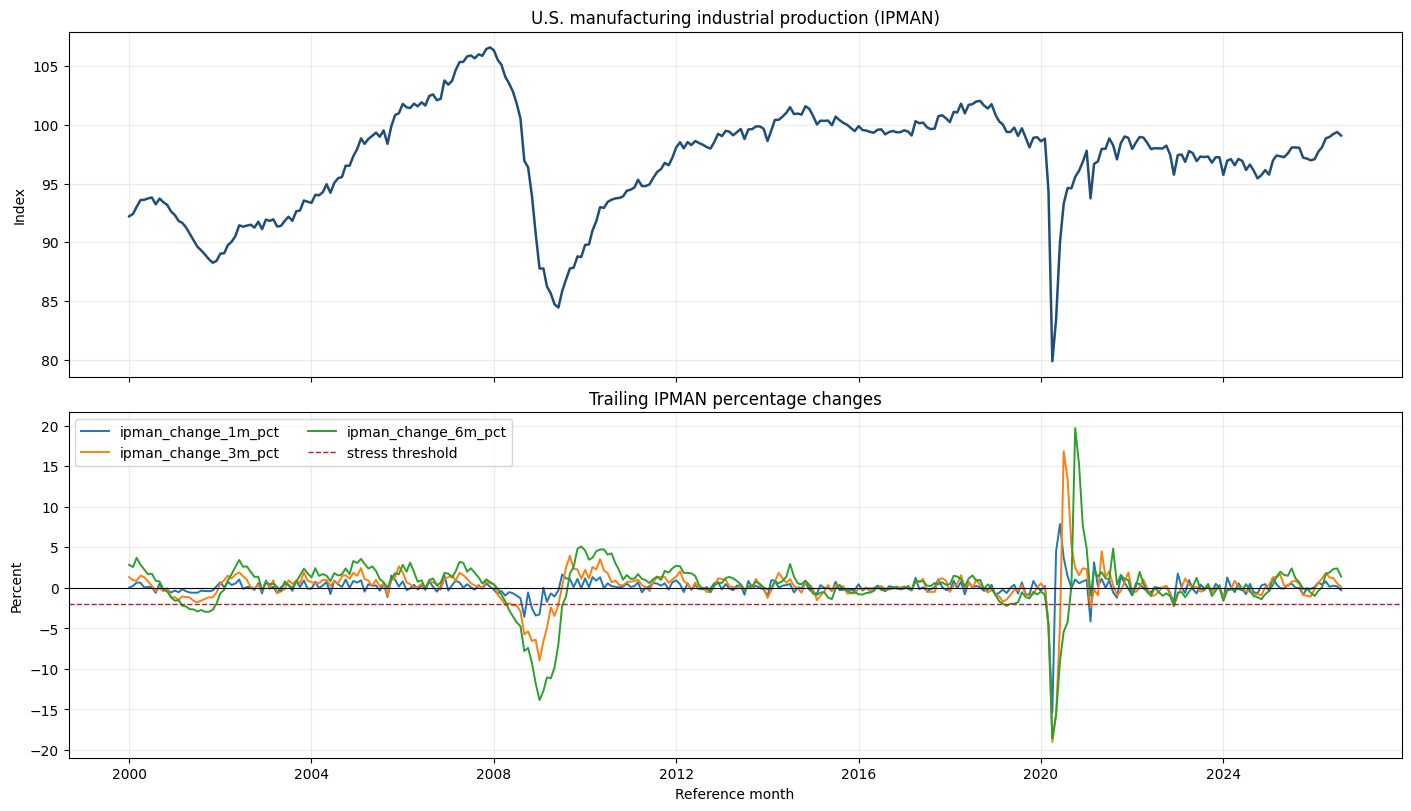

In [27]:

def in_analysis_window(frame: pd.DataFrame) -> pd.DataFrame:
    mask = frame["timestamp"] >= ANALYSIS_START_TS
    if ANALYSIS_END_TS is not None:
        mask &= frame["timestamp"] <= ANALYSIS_END_TS
    return frame.loc[mask].copy()


ipman = in_analysis_window(series_frames[IPMAN_SERIES_ID])
ipman_momentum = {series_id: in_analysis_window(series_frames[series_id]) for series_id in IPMAN_FEATURE_SERIES_IDS}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, layout="constrained")
axes[0].plot(ipman["timestamp"], ipman["value"], color="#1f4e79", linewidth=1.8)
axes[0].set(title="U.S. manufacturing industrial production (IPMAN)", ylabel="Index")
axes[0].grid(alpha=0.25)
for series_id, frame in ipman_momentum.items():
    axes[1].plot(frame["timestamp"], frame["value"], linewidth=1.4, label=series_id)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline(DEFAULT_STRESS_THRESHOLD_PCT, color="#b22222", linestyle="--", linewidth=1.0, label="stress threshold")
axes[1].set(title="Trailing IPMAN percentage changes", xlabel="Reference month", ylabel="Percent")
axes[1].legend(ncol=2)
axes[1].grid(alpha=0.25)
plt.show()

## Target construction and event frequency

A stress month has a trailing three-month IPMAN change at or below $-2\%$. The target is known only once the current IPMAN observation is released, and the forecasting task predicts the target three months ahead.

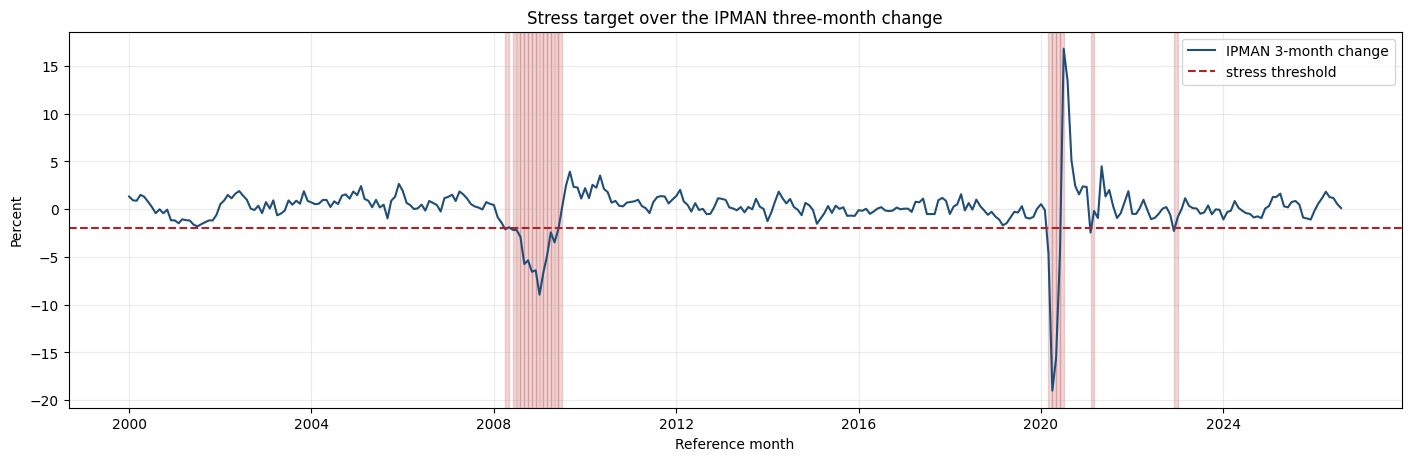

,stress_months,observed_months,stress_base_rate,lookback_months,threshold_pct
0,20,320,0.0625,3,-2.0


In [7]:
reconstructed_target = derive_manufacturing_stress_labels(
    series_frames[IPMAN_SERIES_ID],
    lookback_months=DEFAULT_LOOKBACK_MONTHS,
    threshold_pct=DEFAULT_STRESS_THRESHOLD_PCT,
).rename(columns={"value": "reconstructed_target"})
registered_target = series_frames[STRESS_SERIES_ID].rename(columns={"value": "registered_target"})
target_check = reconstructed_target.merge(
    registered_target[["timestamp", "registered_target"]], on="timestamp", how="inner"
)
if not target_check["reconstructed_target"].equals(target_check["registered_target"]):
    raise AssertionError("The registered target does not match the IPMAN-derived target.")

target = in_analysis_window(registered_target).dropna(subset=["registered_target"]).copy()
ipman_change_3m = in_analysis_window(series_frames[IPMAN_CHANGE_3M_SERIES_ID])
stress_months = target.loc[target["registered_target"] == 1, "timestamp"]

fig, ax = plt.subplots(figsize=(14, 4.5), layout="constrained")
ax.plot(ipman_change_3m["timestamp"], ipman_change_3m["value"], color="#1f4e79", label="IPMAN 3-month change")
ax.axhline(DEFAULT_STRESS_THRESHOLD_PCT, color="#b22222", linestyle="--", label="stress threshold")
for timestamp in stress_months:
    ax.axvspan(timestamp, timestamp + pd.offsets.MonthEnd(1), color="#b22222", alpha=0.18)
ax.set(title="Stress target over the IPMAN three-month change", xlabel="Reference month", ylabel="Percent")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

target_summary = pd.DataFrame(
    {
        "stress_months": [int(target["registered_target"].sum())],
        "observed_months": [len(target)],
        "stress_base_rate": [target["registered_target"].mean()],
        "lookback_months": [DEFAULT_LOOKBACK_MONTHS],
        "threshold_pct": [DEFAULT_STRESS_THRESHOLD_PCT],
    }
)
target_summary

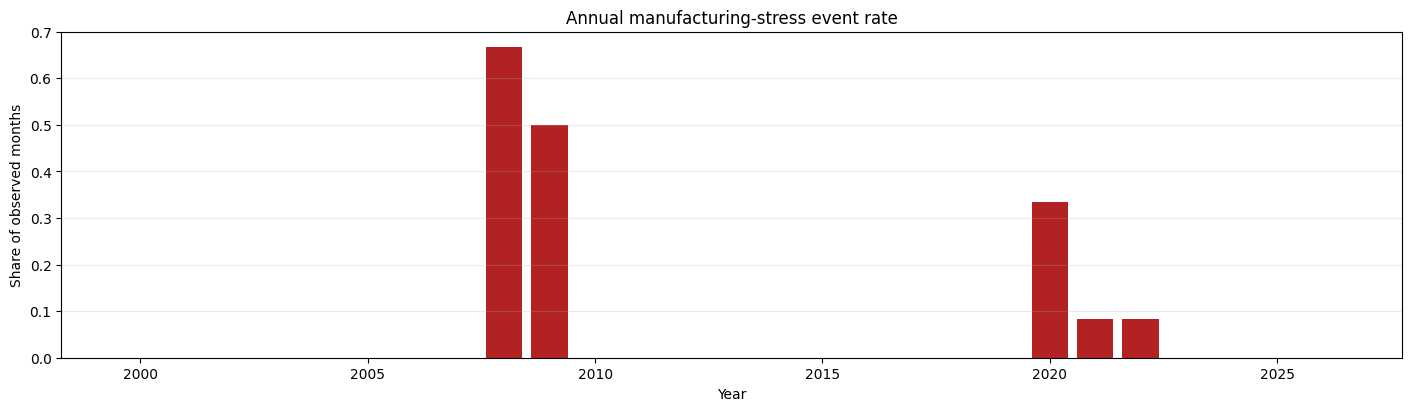

,year,stress_months,observed_months,stress_rate
0,2000,0.0,12,0.000000
1,2001,0.0,12,0.000000
2,2002,0.0,12,0.000000
3,2003,0.0,12,0.000000
4,2004,0.0,12,0.000000
5,2005,0.0,12,0.000000
6,2006,0.0,12,0.000000
7,2007,0.0,12,0.000000
8,2008,8.0,12,0.666667
9,2009,6.0,12,0.500000


In [8]:
annual_target_rate = (
    target.assign(year=target["timestamp"].dt.year)
    .groupby("year", as_index=False)["registered_target"]
    .agg(stress_months="sum", observed_months="count", stress_rate="mean")
)

fig, ax = plt.subplots(figsize=(14, 4), layout="constrained")
ax.bar(annual_target_rate["year"], annual_target_rate["stress_rate"], color="#b22222")
ax.set(title="Annual manufacturing-stress event rate", xlabel="Year", ylabel="Share of observed months")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.25)
plt.show()
annual_target_rate

## Macro, risk, market, and supply-chain trends

The source data have different units, so each feature receives its own axis. Daily/weekly source series have already been reduced to monthly observations; SPY and XLI are trailing monthly-origin returns.

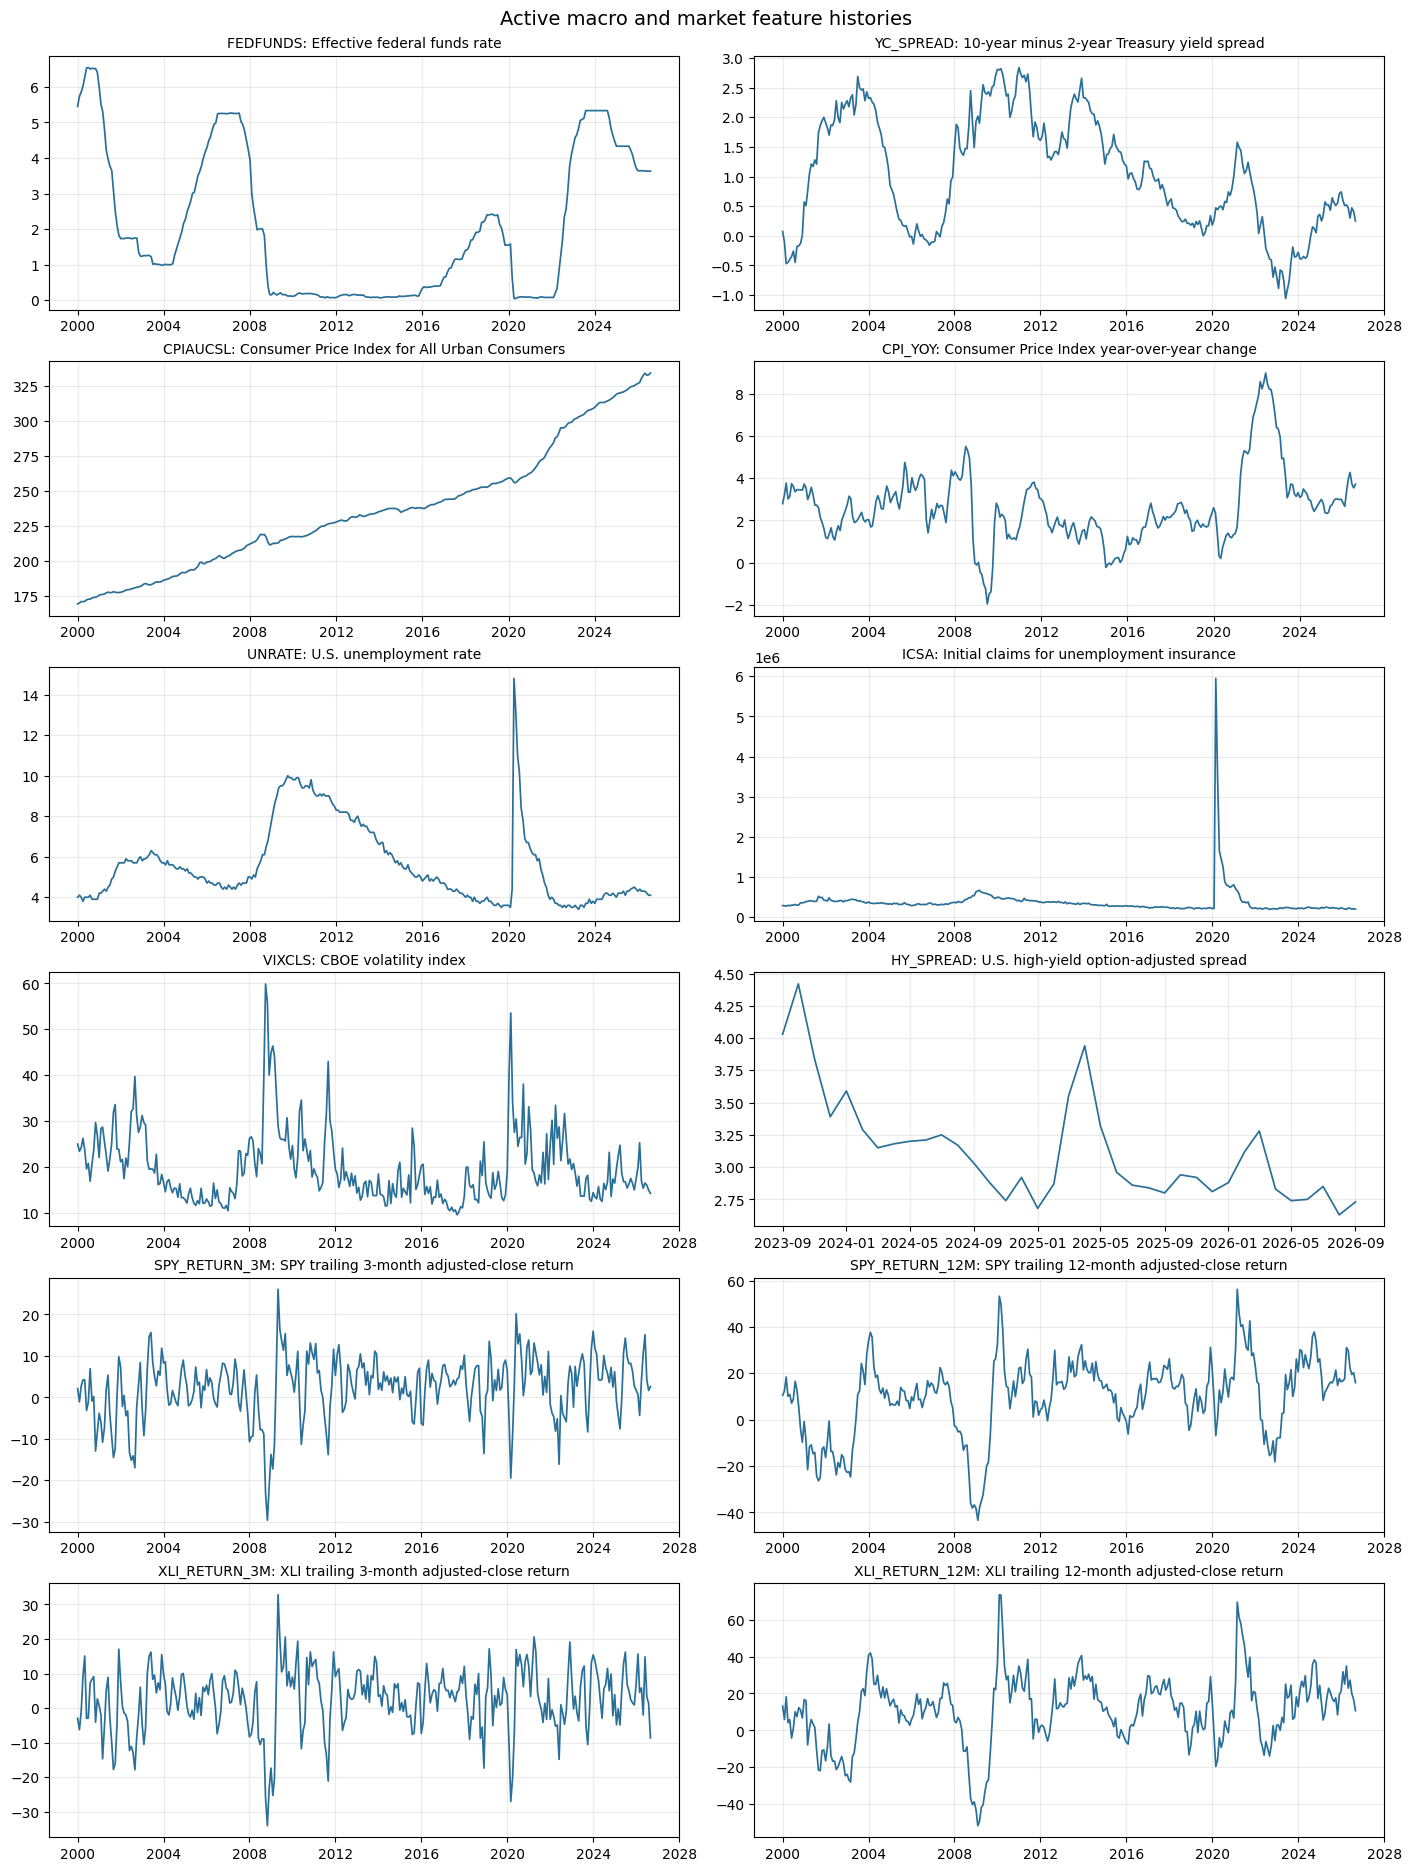

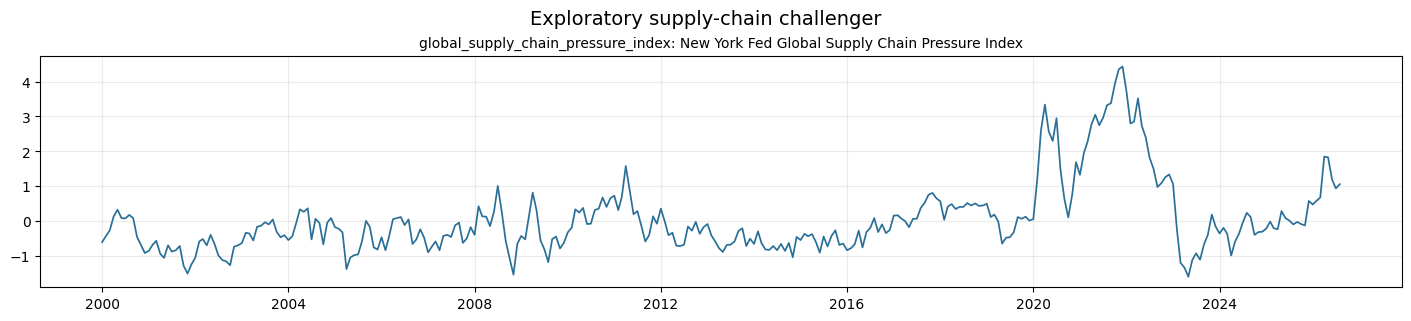

In [ ]:

def plot_series_grid(series_ids: tuple[str, ...], title: str, columns: int = 2) -> None:
    rows = int(np.ceil(len(series_ids) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(14, 3.1 * rows), squeeze=False, layout="constrained")
    for axis, series_id in zip(axes.flat, series_ids, strict=False):
        frame = in_analysis_window(series_frames[series_id])
        label = service_summary.loc[service_summary["series_id"] == series_id, "description"].iloc[0]
        axis.plot(frame["timestamp"], frame["value"], color="#2a6f97", linewidth=1.25)
        axis.set_title(f"{series_id}: {label}", fontsize=10)
        axis.grid(alpha=0.25)
    for axis in axes.flat[len(series_ids) :]:
        axis.set_visible(False)
    fig.suptitle(title, fontsize=14)
    plt.show()


plot_series_grid(MACRO_FEATURE_SERIES_IDS, "Active macro and market feature histories")

## Build a timestamp-aligned analysis panel

This panel is intentionally for descriptive analysis: values are aligned on their reference month, regardless of when they were released. Missing early history remains missing. Forecasting requires the release-aware snapshots shown later.

In [ ]:
analysis_series_ids = FEATURE_SERIES_IDS
wide_features = pd.concat(
    [
        in_analysis_window(series_frames[series_id])[["timestamp", "value"]].rename(columns={"value": series_id})
        .set_index("timestamp")
        for series_id in analysis_series_ids
    ],
    axis=1,
).sort_index()
analysis_panel = wide_features.join(
    target.set_index("timestamp")[["registered_target"]].rename(columns={"registered_target": "target"}),
    how="outer",
)
analysis_panel = analysis_panel.join(
    ipman_change_3m.set_index("timestamp")[["value"]].rename(columns={"value": "ipman_change_3m"}),
    how="outer",
)

panel_coverage = pd.DataFrame(
    {
        "non_missing_months": analysis_panel.notna().sum(),
        "first_available": analysis_panel.apply(lambda column: column.first_valid_index()),
        "last_available": analysis_panel.apply(lambda column: column.last_valid_index()),
    }
).sort_values("non_missing_months")
print(f"Analysis panel reference months: {analysis_panel.index.min().date()} to {analysis_panel.index.max().date()}")
panel_coverage

Analysis panel reference months: 2000-01-01 to 2026-09-01


,non_missing_months,first_available,last_available
HY_SPREAD,37,2023-09-01,2026-09-01
CPI_YOY,319,2000-01-01,2026-08-01
CPIAUCSL,319,2000-01-01,2026-08-01
UNRATE,319,2000-01-01,2026-08-01
FEDFUNDS,320,2000-01-01,2026-08-01
ipman_change_6m_pct,320,2000-01-01,2026-08-01
ipman_change_3m_pct,320,2000-01-01,2026-08-01
ipman_change_1m_pct,320,2000-01-01,2026-08-01
global_supply_chain_pressure_index,320,2000-01-01,2026-08-01
target,320,2000-01-01,2026-08-01


## Distributions, rolling behavior, and stress regimes

The binary target is rare, so compare regime summaries alongside their counts. Rolling statistics are descriptive and may overlap because returns and IPMAN changes themselves use trailing windows.

In [12]:
summary_statistics = analysis_panel[list(analysis_series_ids)].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).T
summary_statistics[["count", "mean", "std", "min", "5%", "50%", "95%", "max"]]

,count,mean,std,min,5%,50%,95%,max
ipman_change_1m_pct,320.0,0.031235,1.289274,-15.371556,-0.972916,0.043089,1.163776,7.858989e+00
ipman_change_3m_pct,320.0,0.104482,2.384910,-19.013071,-2.179607,0.221818,2.210450,1.681345e+01
ipman_change_6m_pct,320.0,0.217812,3.263535,-18.585385,-4.273020,0.475021,3.461830,1.967475e+01
FEDFUNDS,320.0,2.048469,2.022276,0.050000,0.080000,1.375000,5.330000,6.540000e+00
YC_SPREAD,321.0,1.041059,0.962217,-1.060000,-0.390000,0.990000,2.540000,2.840000e+00
CPIAUCSL,319.0,235.635251,43.461518,169.300000,177.210000,232.282000,319.836700,3.341310e+02
CPI_YOY,319.0,2.608072,1.718826,-1.958761,0.032414,2.420261,5.985543,8.979361e+00
UNRATE,319.0,5.609404,1.932388,3.400000,3.600000,5.000000,9.500000,1.480000e+01
ICSA,321.0,371890.965732,391182.698620,190000.000000,207000.000000,318000.000000,620000.000000,5.946000e+06
VIXCLS,321.0,19.789502,7.743577,9.510000,11.570000,17.520000,33.400000,5.989000e+01


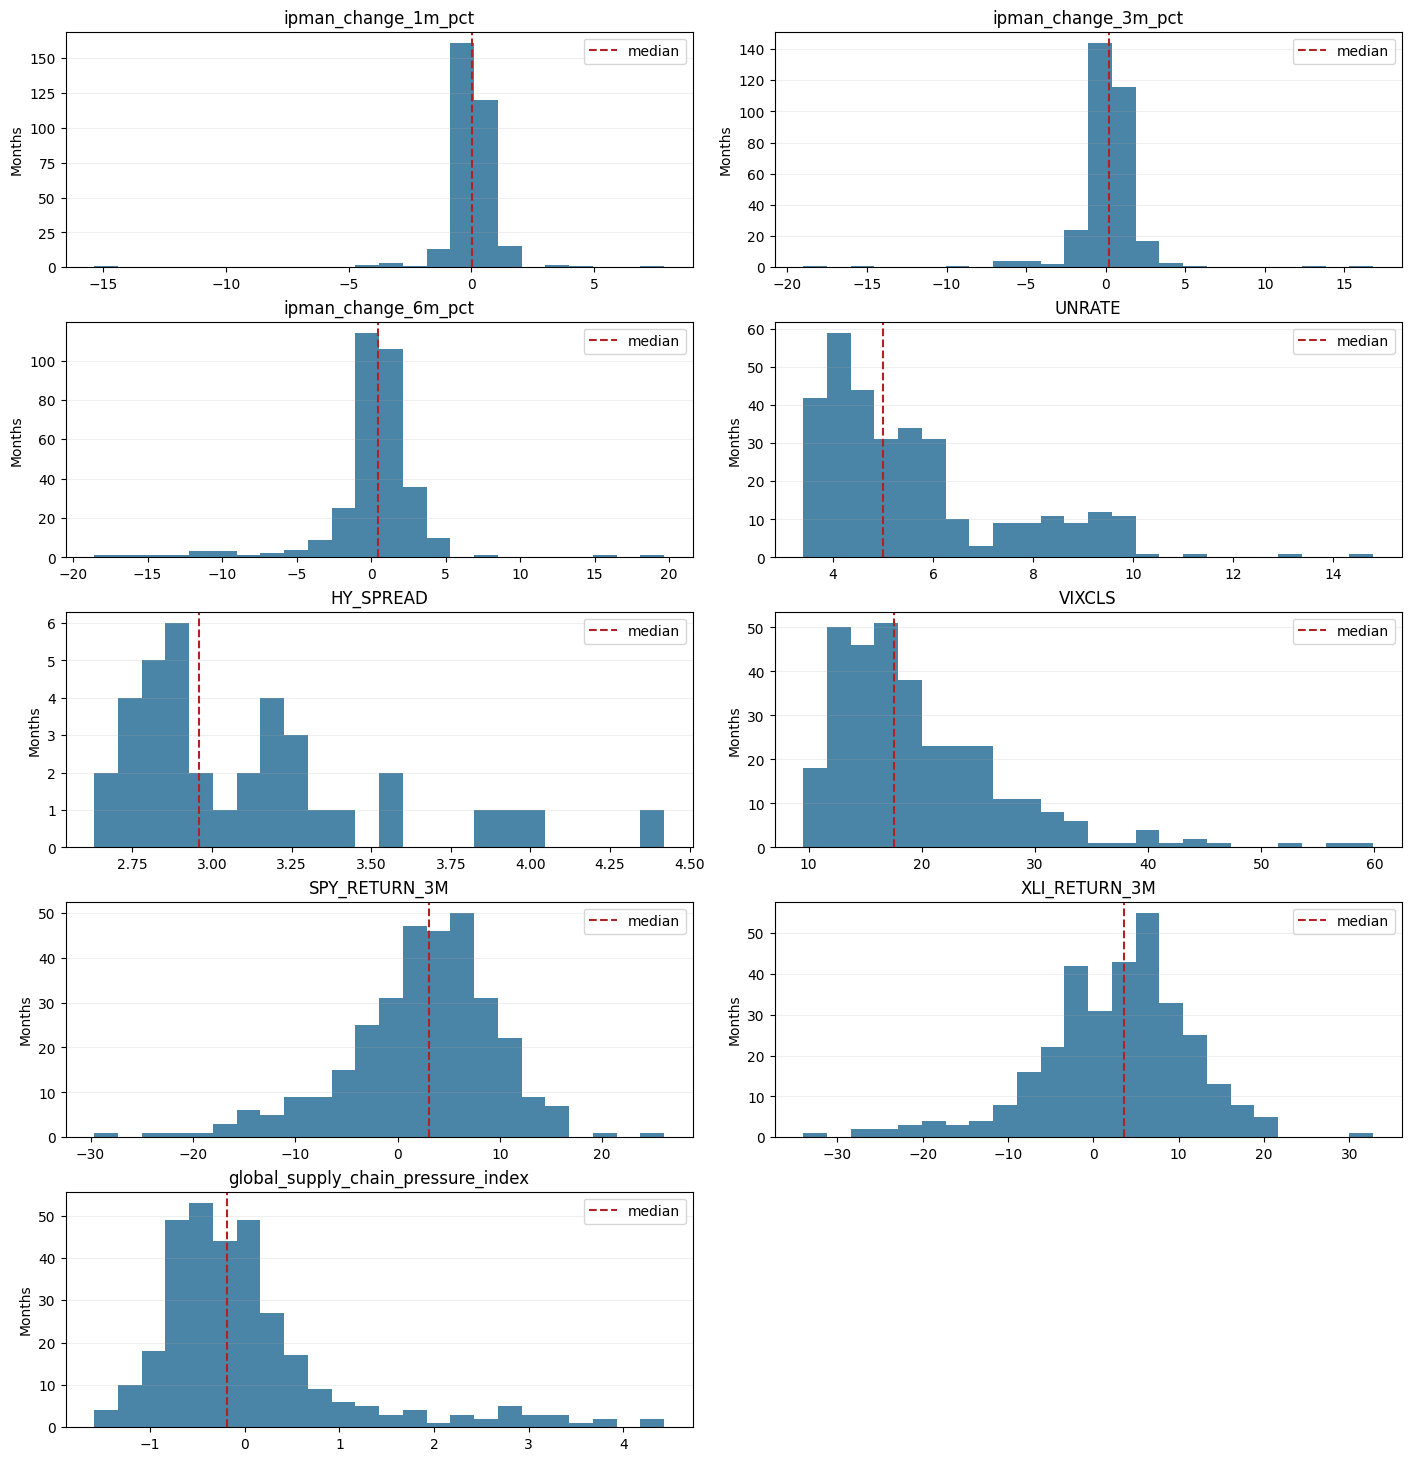

In [ ]:
distribution_ids = IPMAN_FEATURE_SERIES_IDS + tuple(
    series_id for series_id in MACRO_FEATURE_SERIES_IDS if series_id in analysis_panel.columns
)
rows = int(np.ceil(len(distribution_ids) / 2))
fig, axes = plt.subplots(rows, 2, figsize=(14, 2.9 * rows), squeeze=False, layout="constrained")
for axis, series_id in zip(axes.flat, distribution_ids, strict=False):
    values = analysis_panel[series_id].dropna()
    axis.hist(values, bins=24, color="#2a6f97", alpha=0.85)
    axis.axvline(values.median(), color="#b22222", linestyle="--", label="median")
    axis.set(title=series_id, ylabel="Months")
    axis.legend()
    axis.grid(axis="y", alpha=0.2)
for axis in axes.flat[len(distribution_ids) :]:
    axis.set_visible(False)
plt.show()

In [14]:
regime_rows = []
for series_id in analysis_series_ids:
    paired = analysis_panel[[series_id, "target"]].dropna()
    for regime_value, regime_name in ((0, "no_stress"), (1, "stress")):
        values = paired.loc[paired["target"] == regime_value, series_id]
        regime_rows.append(
            {
                "series_id": series_id,
                "regime": regime_name,
                "months": len(values),
                "mean": values.mean(),
                "median": values.median(),
                "std": values.std(),
            }
        )
regime_summary = pd.DataFrame(regime_rows)
regime_summary.pivot(index="series_id", columns="regime", values=["months", "mean", "median"])

months                  mean  \
regime                             no_stress stress      no_stress   
series_id                                                            
CPIAUCSL                               299.0   20.0     236.023726   
CPI_YOY                                299.0   20.0       2.659345   
FEDFUNDS                               300.0   20.0       2.125967   
HY_SPREAD                               36.0    0.0       3.135000   
ICSA                                   300.0   20.0  327880.000000   
SPY_RETURN_12M                         300.0   20.0      11.576986   
SPY_RETURN_3M                          300.0   20.0       2.752578   
UNRATE                                 299.0   20.0       5.466221   
VIXCLS                                 300.0   20.0      18.774733   
XLI_RETURN_12M                         300.0   20.0      12.851540   
XLI_RETURN_3M                          300.0   20.0       3.221800   
YC_SPREAD                              300.0   20.0       1.015633   
global_supply_chain_pressure_index     300.0   20.0       0.007633   
ipman_change_1m_pct                    300.0   20.0       0.148638   
ipman_change_3m_pct                    300.0   20.0       0.479947   
ipman_change_6m_pct                    300.0   20.0       0.789186   

                                                         median                 
regime                                    stress      no_stress         stress  
series_id                                                                       
CPIAUCSL                            2.298276e+02     233.456000     217.229000  
CPI_YOY                             1.841541e+00       2.470996       0.908287  
FEDFUNDS                            8.860000e-01       1.530000       0.215000  
HY_SPREAD                                    NaN       2.995000            NaN  
ICSA                                1.040800e+06  312000.000000  600500.000000  
SPY_RETURN_12M                     -1.802432e+01      13.666769     -20.271753  
SPY_RETURN_3M                      -4.298742e+00       3.502630      -7.792887  
UNRATE                              7.750000e+00       4.900000       7.050000  
VIXCLS                              3.529000e+01      17.070000      32.290000  
XLI_RETURN_12M                     -2.262600e+01      13.493396     -21.568725  
XLI_RETURN_3M                      -6.712314e+00       3.880771      -8.919493  
YC_SPREAD                           1.462000e+00       0.945000       1.485000  
global_supply_chain_pressure_index  5.880000e-01      -0.200000       0.270000  
ipman_change_1m_pct                -1.729804e+00       0.068005      -1.181206  
ipman_change_3m_pct                -5.527494e+00       0.298977      -4.645436  
ipman_change_6m_pct                -8.352793e+00       0.622155      -8.435298

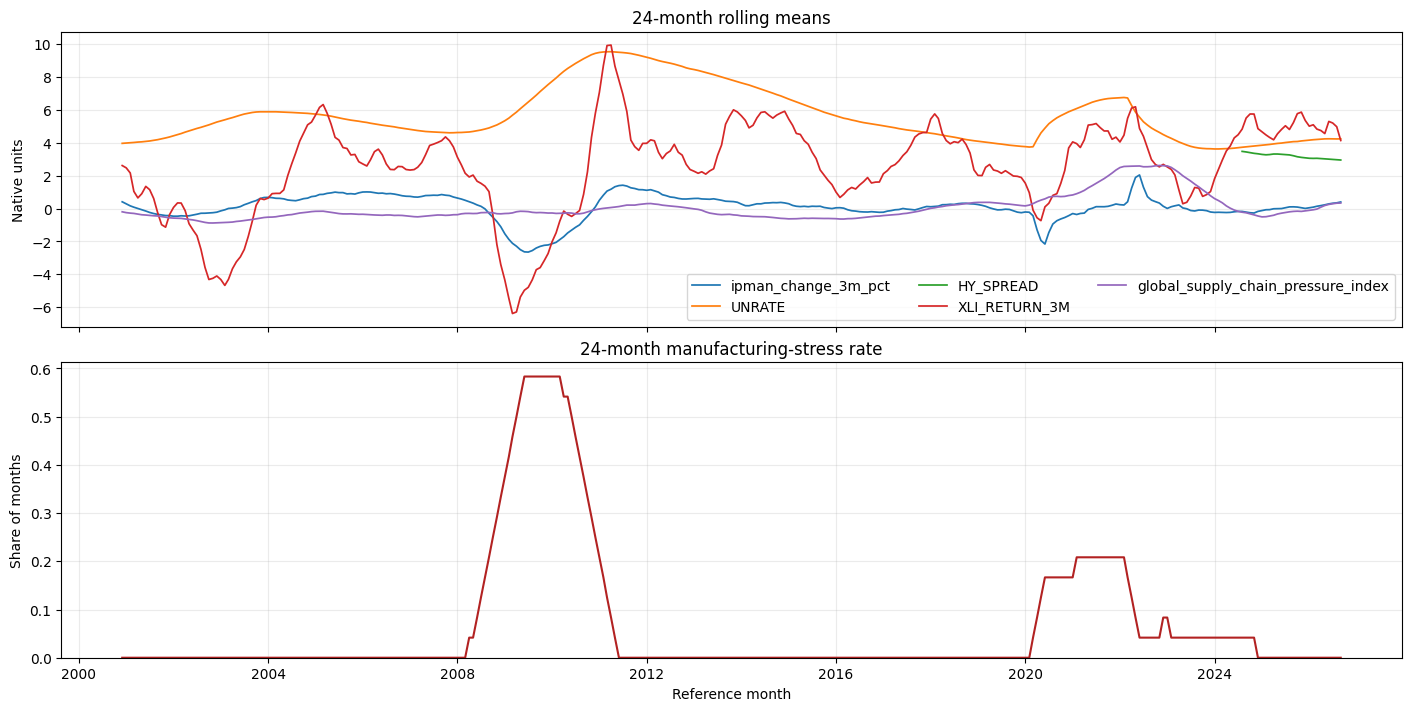

In [ ]:
rolling_ids = (IPMAN_CHANGE_3M_SERIES_ID,) + tuple(
    series_id for series_id in MACRO_FEATURE_SERIES_IDS if series_id in analysis_panel.columns
)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, layout="constrained")
for series_id in rolling_ids:
    axes[0].plot(
        analysis_panel.index,
        analysis_panel[series_id].rolling(ROLLING_WINDOW_MONTHS, min_periods=12).mean(),
        linewidth=1.25,
        label=series_id,
    )
axes[0].set(title=f"{ROLLING_WINDOW_MONTHS}-month rolling means", ylabel="Native units")
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.25)
axes[1].plot(
    analysis_panel.index,
    analysis_panel["target"].rolling(ROLLING_WINDOW_MONTHS, min_periods=12).mean(),
    color="#b22222",
)
axes[1].set(title=f"{ROLLING_WINDOW_MONTHS}-month manufacturing-stress rate", xlabel="Reference month", ylabel="Share of months")
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.25)
plt.show()

## Contemporaneous correlations

Pearson summarizes linear co-movement; Spearman summarizes rank co-movement. Both require overlapping observed months and neither identifies causality. The target association is equivalent to a point-biserial correlation when using Pearson because the target is binary.

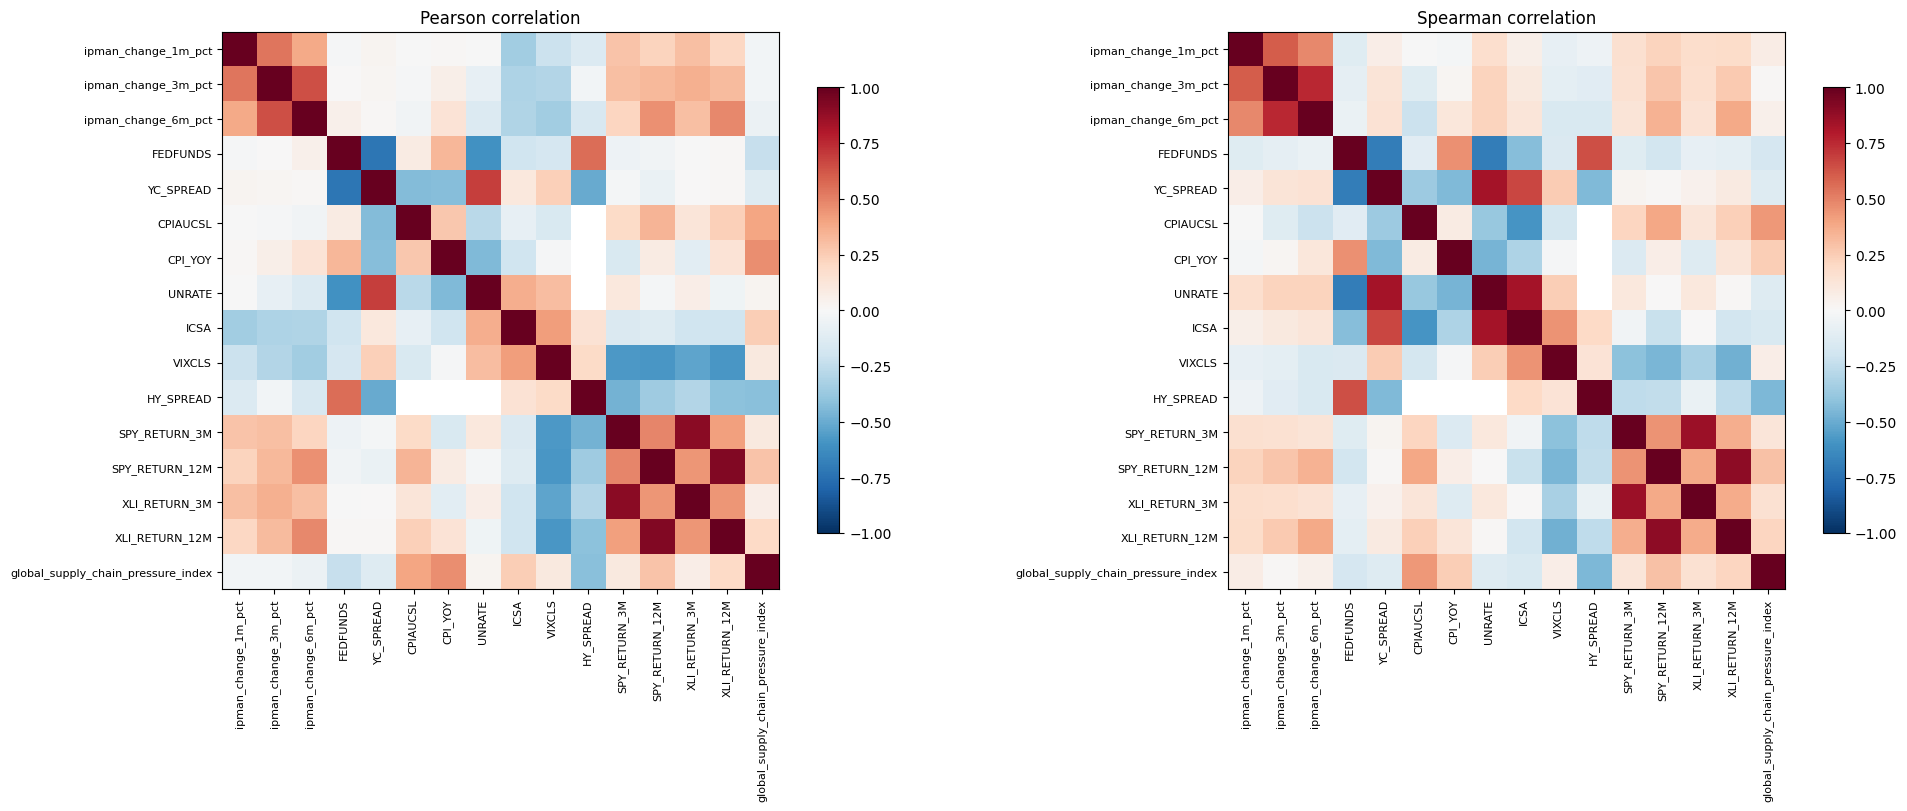

In [16]:
correlation_data = analysis_panel[list(analysis_series_ids)]
pearson_correlation = correlation_data.corr(method="pearson", min_periods=36)
spearman_correlation = correlation_data.corr(method="spearman", min_periods=36)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), layout="constrained")
for axis, matrix, title in zip(
    axes,
    (pearson_correlation, spearman_correlation),
    ("Pearson correlation", "Spearman correlation"),
    strict=False,
):
    image = axis.imshow(matrix, vmin=-1, vmax=1, cmap="RdBu_r")
    axis.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=90, fontsize=8)
    axis.set_yticks(range(len(matrix.index)), matrix.index, fontsize=8)
    axis.set_title(title)
    fig.colorbar(image, ax=axis, shrink=0.8)
plt.show()

In [17]:
target_associations = []
for series_id in analysis_series_ids:
    paired = analysis_panel[[series_id, "target"]].dropna()
    target_associations.append(
        {
            "series_id": series_id,
            "overlapping_months": len(paired),
            "stress_months": int(paired["target"].sum()),
            "pearson_with_target": paired.corr(method="pearson").iloc[0, 1],
            "spearman_with_target": paired.corr(method="spearman").iloc[0, 1],
        }
    )
target_associations = pd.DataFrame(target_associations).sort_values("pearson_with_target", key=np.abs, ascending=False)
target_associations

,series_id,overlapping_months,stress_months,pearson_with_target,spearman_with_target
2,ipman_change_6m_pct,320,20,-0.679137,-0.408783
1,ipman_change_3m_pct,320,20,-0.610693,-0.419265
9,VIXCLS,320,20,0.516682,0.344217
14,XLI_RETURN_12M,320,20,-0.459119,-0.342819
8,ICSA,320,20,0.441289,0.333253
12,SPY_RETURN_12M,320,20,-0.434290,-0.314309
0,ipman_change_1m_pct,320,20,-0.353230,-0.297538
7,UNRATE,319,20,0.286947,0.227658
13,XLI_RETURN_3M,320,20,-0.272043,-0.169383
11,SPY_RETURN_3M,320,20,-0.230846,-0.148979


## Lagged cross-correlations

For a lag $k$, this section correlates the feature observed in month $t$ with the outcome at $t+k$. Positive lags are the forecast-relevant direction: for example, `lag_months = 3` compares a month-$t$ feature with manufacturing stress or IPMAN momentum three months later. Negative lags are included as diagnostic context only.

In [18]:
lag_rows = []
for series_id in analysis_series_ids:
    feature = analysis_panel[series_id]
    for lag in range(-CORRELATION_LAG_MONTHS, CORRELATION_LAG_MONTHS + 1):
        for outcome_name in ("target", "ipman_change_3m"):
            paired = pd.concat(
                [feature.rename("feature"), analysis_panel[outcome_name].shift(-lag).rename("outcome")],
                axis=1,
            ).dropna()
            lag_rows.append(
                {
                    "series_id": series_id,
                    "outcome": outcome_name,
                    "lag_months": lag,
                    "overlapping_months": len(paired),
                    "pearson_correlation": paired.corr(method="pearson").iloc[0, 1] if len(paired) >= 12 else np.nan,
                    "spearman_correlation": paired.corr(method="spearman").iloc[0, 1] if len(paired) >= 12 else np.nan,
                }
            )
lag_correlations = pd.DataFrame(lag_rows)
forecast_relevant_lags = lag_correlations.query("lag_months >= 0").sort_values(
    "pearson_correlation", key=np.abs, ascending=False
)
forecast_relevant_lags.head(20)

,series_id,outcome,lag_months,overlapping_months,pearson_correlation,spearman_correlation
111,ipman_change_3m_pct,ipman_change_3m,0,320,1.000000,1.000000
39,ipman_change_1m_pct,ipman_change_3m,1,319,0.713129,0.551374
184,ipman_change_6m_pct,target,0,320,-0.679137,-0.408783
113,ipman_change_3m_pct,ipman_change_3m,1,319,0.677362,0.703910
185,ipman_change_6m_pct,ipman_change_3m,0,320,0.642045,0.757187
110,ipman_change_3m_pct,target,0,320,-0.610693,-0.419265
186,ipman_change_6m_pct,target,1,319,-0.598950,-0.357949
41,ipman_change_1m_pct,ipman_change_3m,2,318,0.588770,0.635415
112,ipman_change_3m_pct,target,1,319,-0.545659,-0.355000
37,ipman_change_1m_pct,ipman_change_3m,0,320,0.533766,0.603456


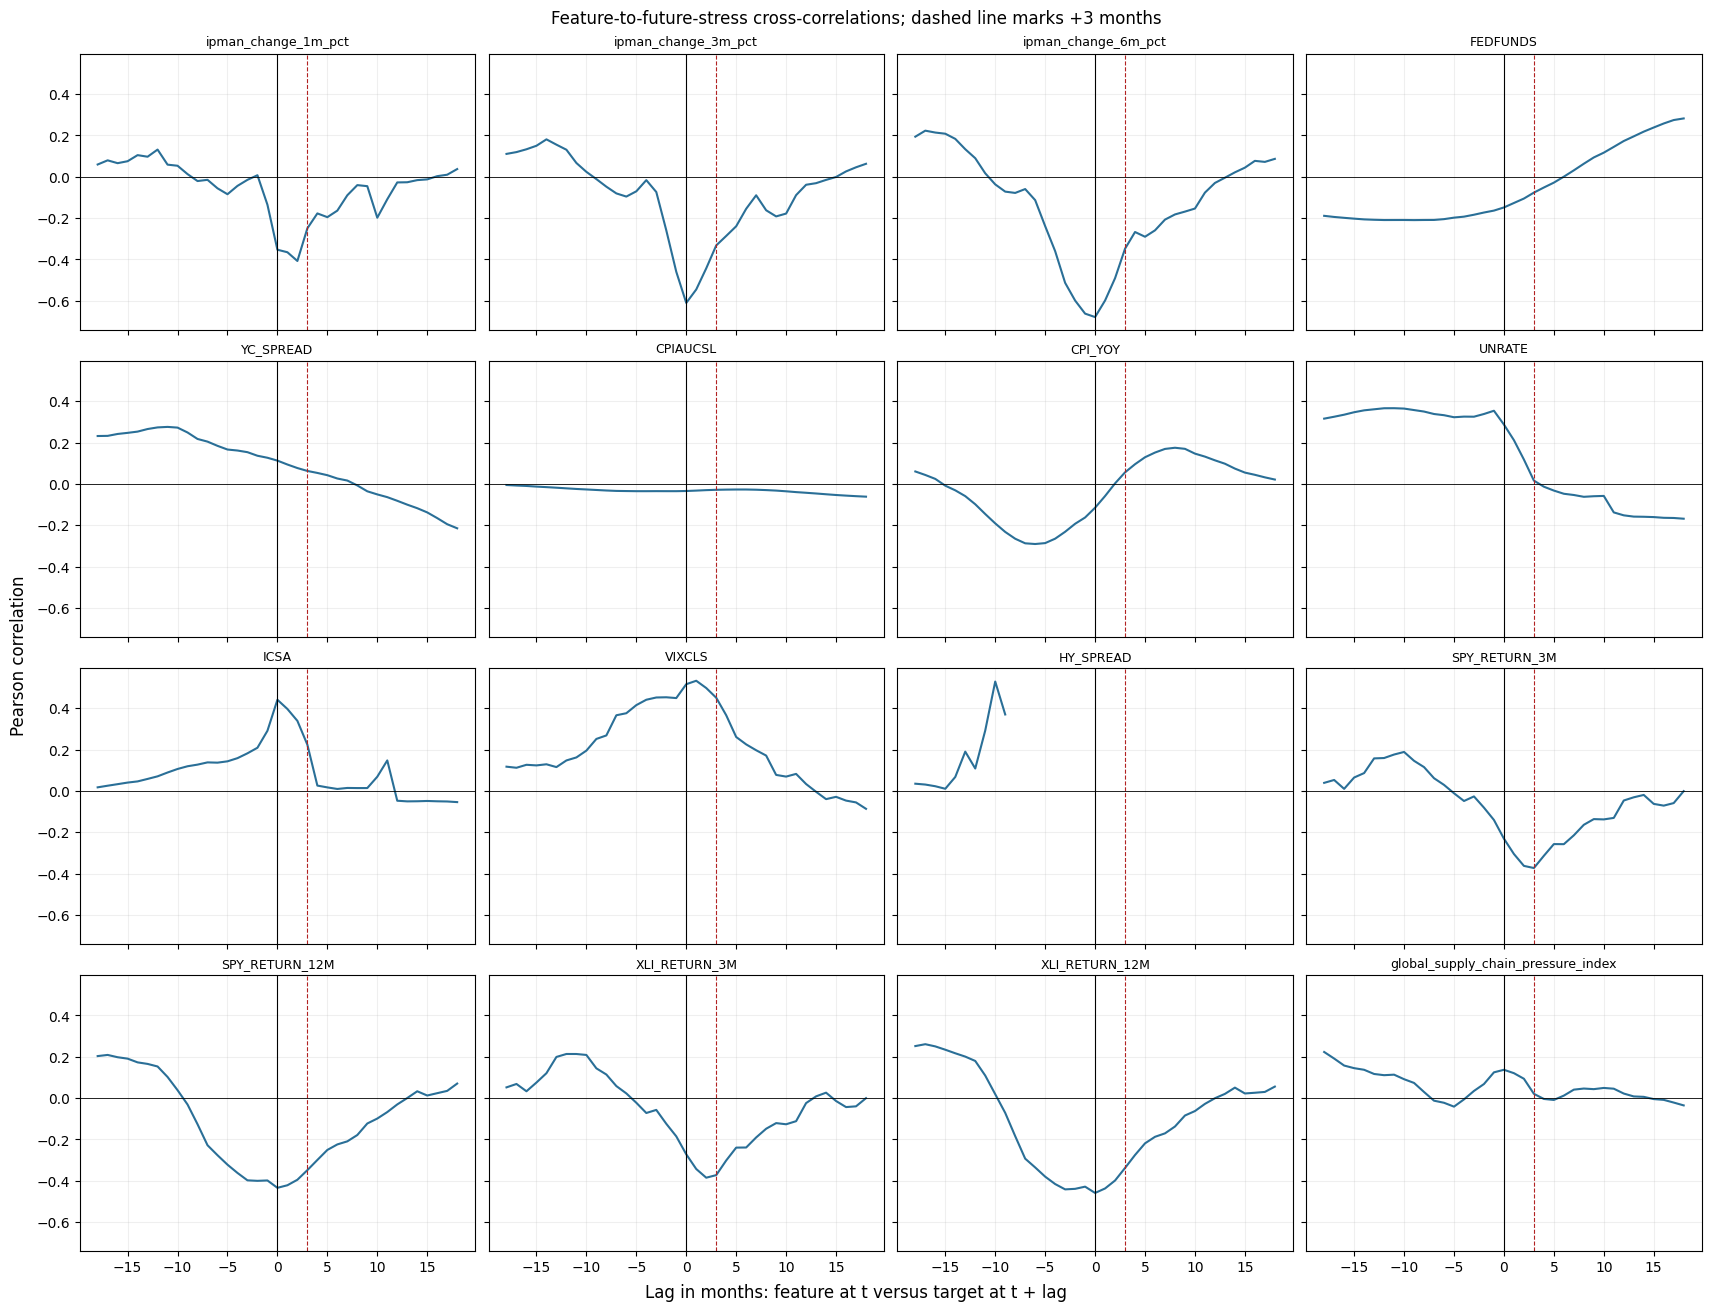

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(17, 13), sharex=True, sharey=True, layout="constrained")
for axis, series_id in zip(axes.flat, analysis_series_ids, strict=False):
    subset = lag_correlations.query("series_id == @series_id and outcome == 'target'")
    axis.plot(subset["lag_months"], subset["pearson_correlation"], color="#2a6f97")
    axis.axvline(0, color="black", linewidth=0.8)
    axis.axvline(3, color="#b22222", linestyle="--", linewidth=0.8)
    axis.axhline(0, color="black", linewidth=0.6)
    axis.set_title(series_id, fontsize=9)
    axis.grid(alpha=0.2)
for axis in axes.flat[len(analysis_series_ids) :]:
    axis.set_visible(False)
fig.supxlabel("Lag in months: feature at t versus target at t + lag")
fig.supylabel("Pearson correlation")
fig.suptitle("Feature-to-future-stress cross-correlations; dashed line marks +3 months")
plt.show()

## Small-sample robustness check

Only 20 of 320 observed months are labeled stress, so a target correlation can be dominated by a handful of episodes. For the top non-mechanical candidates (excluding the IPMAN-derived features, which are related to the target by construction), this section reports a bootstrap confidence interval on the point-biserial correlation and a leave-one-stress-month-out sensitivity range. A wide bootstrap interval, a sign flip under leave-one-out, or a large leave-one-out swing all indicate the descriptive correlation is fragile and should not be treated as a strong feature-selection signal on its own.

In [29]:
N_BOOTSTRAP = 2000
robustness_rng = np.random.default_rng(0)


def point_biserial(paired: pd.DataFrame) -> float:
    return paired.corr(method="pearson").iloc[0, 1]


robustness_candidates = (
    target_associations.query("series_id not in @IPMAN_FEATURE_SERIES_IDS and stress_months > 0")
    .head(6)["series_id"]
    .tolist()
)

robustness_rows = []
for series_id in robustness_candidates:
    paired = analysis_panel[[series_id, "target"]].dropna()
    point_estimate = point_biserial(paired)

    bootstrap_estimates = np.array(
        [
            point_biserial(paired.sample(n=len(paired), replace=True, random_state=robustness_rng.integers(0, 1_000_000)))
            for _ in range(N_BOOTSTRAP)
        ]
    )

    stress_timestamps = paired.index[paired["target"] == 1]
    loo_estimates = np.array(
        [point_biserial(paired.drop(index=stress_timestamp)) for stress_timestamp in stress_timestamps]
    )

    robustness_rows.append(
        {
            "series_id": series_id,
            "point_estimate": point_estimate,
            "bootstrap_ci_low": np.percentile(bootstrap_estimates, 2.5),
            "bootstrap_ci_high": np.percentile(bootstrap_estimates, 97.5),
            "loo_min": loo_estimates.min(),
            "loo_max": loo_estimates.max(),
            "loo_swing": loo_estimates.max() - loo_estimates.min(),
            "sign_stable_under_loo": bool(np.all(np.sign(loo_estimates) == np.sign(point_estimate))),
        }
    )

robustness_summary = pd.DataFrame(robustness_rows).sort_values("loo_swing", ascending=False)
robustness_summary


,series_id,point_estimate,bootstrap_ci_low,bootstrap_ci_high,loo_min,loo_max,loo_swing,sign_stable_under_loo
5,XLI_RETURN_3M,-0.272043,-0.471106,-0.053204,-0.327186,-0.233512,0.093674,True
4,UNRATE,0.286947,0.140489,0.425702,0.243455,0.308137,0.064681,True
2,ICSA,0.441289,0.330613,0.579483,0.394551,0.457501,0.062950,True
3,SPY_RETURN_12M,-0.434290,-0.556678,-0.282467,-0.461930,-0.411560,0.050370,True
1,XLI_RETURN_12M,-0.459119,-0.573176,-0.325573,-0.481412,-0.436542,0.044871,True
0,VIXCLS,0.516682,0.366911,0.637856,0.485727,0.527930,0.042203,True


## Point-in-time feature availability

The preceding descriptive panel aligns reference months. A forecasting origin must instead see only records whose `released_at` is on or before that origin. This reproduces the fit-at-origin feature lookup used by the statistical predictors.

In [21]:
feature_frames = {series_id: series_frames[series_id] for series_id in FEATURE_SERIES_IDS}
candidate_origins = analysis_panel.index[analysis_panel.index >= ANALYSIS_START_TS]
example_origin = None
snapshot = None
for candidate_origin in reversed(candidate_origins):
    candidate_snapshot = build_feature_snapshot(candidate_origin, feature_frames)
    if candidate_snapshot is not None:
        example_origin = candidate_origin
        snapshot = candidate_snapshot
        break
if example_origin is None or snapshot is None:
    raise RuntimeError("No complete cutoff-safe feature snapshot is available in the analysis window.")

print(f"Latest complete active-feature snapshot: {example_origin.date()}")
availability_audit = []
for series_id in FEATURE_SERIES_IDS:
    visible = feature_frames[series_id].query("released_at <= @example_origin").sort_values("timestamp")
    latest = visible.iloc[-1]
    availability_audit.append(
        {
            "series_id": series_id,
            "origin": example_origin,
            "latest_visible_reference_month": latest["timestamp"],
            "latest_visible_release_date": latest["released_at"],
            "snapshot_value": snapshot[series_id],
        }
    )
pd.DataFrame(availability_audit).sort_values("series_id")

Latest complete active-feature snapshot: 2026-09-01


,series_id,origin,latest_visible_reference_month,latest_visible_release_date,snapshot_value
5,CPIAUCSL,2026-09-01,2026-08-01,2026-08-03,334.131000
6,CPI_YOY,2026-09-01,2026-08-01,2026-08-03,3.712958
3,FEDFUNDS,2026-09-01,2026-08-01,2026-08-03,3.630000
10,HY_SPREAD,2026-09-01,2026-08-01,2026-09-01,2.630000
8,ICSA,2026-09-01,2026-08-01,2026-08-31,207000.000000
12,SPY_RETURN_12M,2026-09-01,2026-08-01,2026-09-01,20.230850
11,SPY_RETURN_3M,2026-09-01,2026-08-01,2026-09-01,1.658482
7,UNRATE,2026-09-01,2026-08-01,2026-08-03,4.100000
9,VIXCLS,2026-09-01,2026-08-01,2026-09-01,14.920000
14,XLI_RETURN_12M,2026-09-01,2026-08-01,2026-09-01,16.694316


## Interpretation checklist

Use the executed tables and charts to record observations here. Keep the distinction between descriptive evidence and forecast evidence intact.

- Coverage and quality: identify sparse starts, gaps, and unusual release delays.
- Target: decide whether the $-2\%$ three-month IPMAN threshold visibly captures the intended stress episodes.
- Contemporaneous relationships: note co-movements that are economically plausible, but do not call them causal.
- Leading candidates: inspect positive lags, especially $+3$ months, then validate any candidate with a cutoff-safe backtest.
- Small-sample robustness: the bootstrap/leave-one-stress-month-out check shows VIXCLS, ICSA, SPY_RETURN_12M, XLI_RETURN_12M, and UNRATE keep a stable sign and a reasonably tight range; XLI_RETURN_3M has the widest bootstrap interval (crossing near zero) and the largest leave-one-out swing, so treat it as the least reliable of the six.
- Caveats: FRED uses current revisions rather than full ALFRED vintages; GSCPI uses the latest revision-table column; overlapping trailing returns and small stress-event counts can exaggerate apparent patterns.

## Current model-input inventory

This section mirrors the variables used by the current manufacturing-stress predictors. The model consumes 15 monthly, cutoff-aware features: three trailing IPMAN changes and twelve macro/market inputs. The target is the binary manufacturing-stress label derived from the trailing three-month IPMAN change. Feature observations use the conservative one-month release lag configured by the service builder.

In [ ]:
from manufacturing_stress_forecasting.features import (
    CREDIT_SPREAD_SERIES_ID,
    FEATURE_SERIES_IDS,
    IPMAN_FEATURE_SERIES_IDS,
    MACRO_FEATURE_SERIES_IDS,
    FEATURE_PERIODS,
)
from manufacturing_stress_forecasting.targets import (
    DEFAULT_LOOKBACK_MONTHS,
    DEFAULT_STRESS_THRESHOLD_PCT,
)

model_input_rows = []
for series_id in IPMAN_FEATURE_SERIES_IDS:
    model_input_rows.append({
        "series_id": series_id,
        "family": "IPMAN momentum",
        "transformation": f"trailing {FEATURE_PERIODS[series_id]}-month percent change",
    })
for series_id in MACRO_FEATURE_SERIES_IDS:
    model_input_rows.append({
        "series_id": series_id,
        "family": "macro/market",
        "transformation": "monthly level or trailing return from data service",
    })

model_input_inventory = pd.DataFrame(model_input_rows)
print(f"Model features: {len(FEATURE_SERIES_IDS)}")
print(f"Target lookback: {DEFAULT_LOOKBACK_MONTHS} months")
print(f"Target threshold: {DEFAULT_STRESS_THRESHOLD_PCT}%")
model_input_inventory

In [ ]:
from pathlib import Path

REPORT_DIR = REPO_ROOT / "implementations" / "manufacturing_stress_forecasting" / "reports" / "data_understanding"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

report_tables = {
    "service_summary": service_summary,
    "variable_dictionary": variable_dictionary,
    "coverage": coverage,
    "summary_statistics": summary_statistics,
    "target_summary": target_summary,
    "annual_target_rate": annual_target_rate,
    "pearson_correlation": pearson_correlation,
    "spearman_correlation": spearman_correlation,
    "lag_correlations": lag_correlations,
    "regime_summary": regime_summary,
    "robustness_summary": robustness_summary,
    "release_gap": release_gap,
    "availability_audit": pd.DataFrame(availability_audit),
    "model_input_inventory": model_input_inventory,
}
for table_name, table in report_tables.items():
    table.to_csv(REPORT_DIR / f"{table_name}.csv", index=True)

feature_columns = [series_id for series_id in FEATURE_SERIES_IDS if series_id in analysis_panel.columns]
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
analysis_panel[feature_columns].plot(ax=axes[0], linewidth=0.8)
axes[0].set_title("Manufacturing Stress Model Features")
axes[0].set_ylabel("Feature value")
axes[0].legend(loc="upper left", ncol=3, fontsize=8)
analysis_panel["target"].plot(ax=axes[1], color="firebrick", drawstyle="steps-post")
axes[1].set_title("Manufacturing Stress Target")
axes[1].set_ylabel("Stress label")
axes[1].set_xlabel("Reference month")
fig.tight_layout()
fig.savefig(REPORT_DIR / "feature_and_target_history.png", dpi=180, bbox_inches="tight")
plt.close(fig)

correlation_columns = feature_columns + [column for column in ["target"] if column in analysis_panel.columns]
correlation_matrix = analysis_panel[correlation_columns].corr(method="spearman")
fig, axis = plt.subplots(figsize=(13, 11))
image = axis.imshow(correlation_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axis.set_xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
axis.set_yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
axis.set_title("Spearman Correlation: Active Features and Target")
fig.colorbar(image, ax=axis, label="Correlation")
fig.tight_layout()
fig.savefig(REPORT_DIR / "active_feature_target_correlation.png", dpi=180, bbox_inches="tight")
plt.close(fig)

coverage_plot = coverage.set_index("series_id")
fig, axis = plt.subplots(figsize=(13, 7))
coverage_plot["observations"].sort_values().plot.barh(ax=axis, color="steelblue")
axis.set_title("Registered Series Observation Counts")
axis.set_xlabel("Observations")
fig.tight_layout()
fig.savefig(REPORT_DIR / "feature_coverage.png", dpi=180, bbox_inches="tight")
plt.close(fig)

availability_plot = pd.DataFrame(availability_audit).sort_values("latest_visible_release_date")
fig, axis = plt.subplots(figsize=(12, 7))
axis.barh(availability_plot["series_id"], availability_plot["latest_visible_release_date"])
axis.axvline(pd.Timestamp(example_origin), color="firebrick", linestyle="--", label="Forecast origin")
axis.set_title("Latest Visible Release Dates at Example Forecast Origin")
axis.set_xlabel("Release date")
axis.legend()
fig.tight_layout()
fig.savefig(REPORT_DIR / "cutoff_safe_release_availability.png", dpi=180, bbox_inches="tight")
plt.close(fig)

print(f"Wrote {len(report_tables)} CSV reports and 4 PNG graphs to {REPORT_DIR}")